# Priority Flow: Workflow Example


This notebook walks through a typical workflow for processing a DEM to ensure a fully connected hydrologic drainage network. For more details on the Priority Flow tool refer to Condon and Maxwell (2019) (https://doi.org/10.1016/j.cageo.2019.01.020)

For this example we will use the sample watershed used in Condon and Maxwell (2019). The DEM and mask files for this domain are provided with the Priority Flow library.

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Import from priority_flow package
from priority_flow import (
    init_queue,
    d4_traverse_b,
    load_dem,
    load_watershed_mask,
    load_river_mask,
    drainage_area,
    calc_subbasins,
    calc_stream_order,
    river_smooth,
    path_extract,
    slope_calc_standard,
    riv_slope,
)

from parflow.tools.io import read_pfb, write_pfb

## Background Information and Setup
Three inputs for domain processing:
1. The unprocessed DEM (Digital Elevation Model)
2. A mask of the watershed we are interested in
3. A mask of our desired drainage network

NOTE: The only required input is a DEM; the other two are optional depending
on how you would like to process things.

In [57]:
# Load test data.
DEM = load_dem().T
watershed_mask = load_watershed_mask().T
river_mask = load_river_mask().T

nx, ny = DEM.shape
print(f"Domain dimensions: nx={nx}, ny={ny}")
print(f"DEM elevation range: {DEM.min():.2f} to {DEM.max():.2f}")

Domain dimensions: nx=172, ny=215
DEM elevation range: 1029.73 to 3310.34


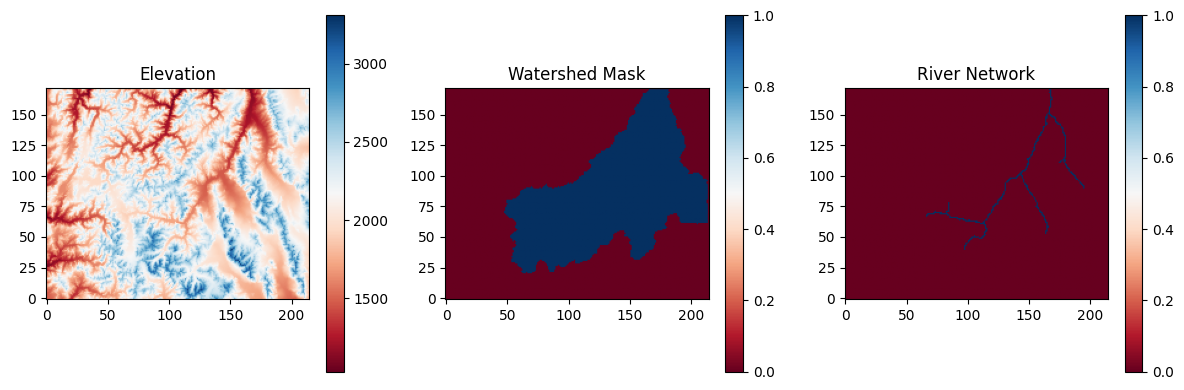

In [58]:
# Plot inputs
def _plot_inputs():
    """Plot the three input datasets."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    im0 = axes[0].imshow(DEM, cmap='RdBu', origin="lower")
    axes[0].set_title("Elevation")
    plt.colorbar(im0, ax=axes[0])
    im1 = axes[1].imshow(watershed_mask, cmap='RdBu', origin="lower")
    axes[1].set_title("Watershed Mask")
    plt.colorbar(im1, ax=axes[1])
    im2 = axes[2].imshow(river_mask, cmap='RdBu', origin="lower")
    axes[2].set_title("River Network")
    plt.colorbar(im2, ax=axes[2])
    plt.tight_layout()
    plt.savefig("workflow_inputs.png", dpi=150)
    plt.show()
    plt.close()

_plot_inputs()

NOTE: The data sets used here are already formatted as [nx,ny] matrices such that the [i,j] indices correspond to the x and y axes of the domain respectively and [0, 0] is the lower left corner and [nx- 1,ny - 1] is the upper right corner. You will need to have your DEM and any other input files formatted like this before you get started. To check that you have them formatted correctly you should be able to do image.plot(yourDEM) and your domain should appear correctly (i.e. untransposed). For plotting, we use the option `origin=lower`.

## Step 1: Processing the DEM
In this step the priority flow algorithm will be used to traverse the raw DEM and ensure that every grid cell in the domain has a pathway to exit along D4 drainage pathways (i.e. there are no unintended internal sinks).  

The primary outcomes of this step are:

1. A processed DEM where elevations have been adjusted to ensure drainage
2. A map of flow directions for every grid cell (Unless a different numbering scheme is specified the following will be used: 1=down, 2=left, 3=up, 4=right) 

There are several ways to complete this processing. They are  listed here in order of increasing complexity.  The primary difference between these approaches is whether you will be limiting processing to some watershed mask and how you initialize the processing. By default Priority Flow will find all of the border cells and set these as the targets ensuring that every other cell in the domain is able to drain to one of the target cells. The initial list of target cells is generated with the init queue function. If you know where the drainage points are in your domain or if you have an internally draining basin where you would like to intentionally set an internal cell as a target point you can make these modifications with the initialization step.


###  Option 1: If you have rectangular DEM and all border cells will be used as target exit points
In this case PriorityFlow will ensure that every grid cell in the domain drains to the edge of the domain without identifying the desired drainage points a priori.

In [59]:
init = init_queue(DEM)

No init mask provided all border cells will be added to queue
No domain mask provided using entire domain
No border provided, setting border using domain mask


In [60]:
#process the DEM
trav_hs = d4_traverse_b(
    DEM,
    init["queue"].copy(),
    init["marked"].copy(),
    basins=init["basins"].copy(),
    epsilon=0,
    n_chunk=10,
)

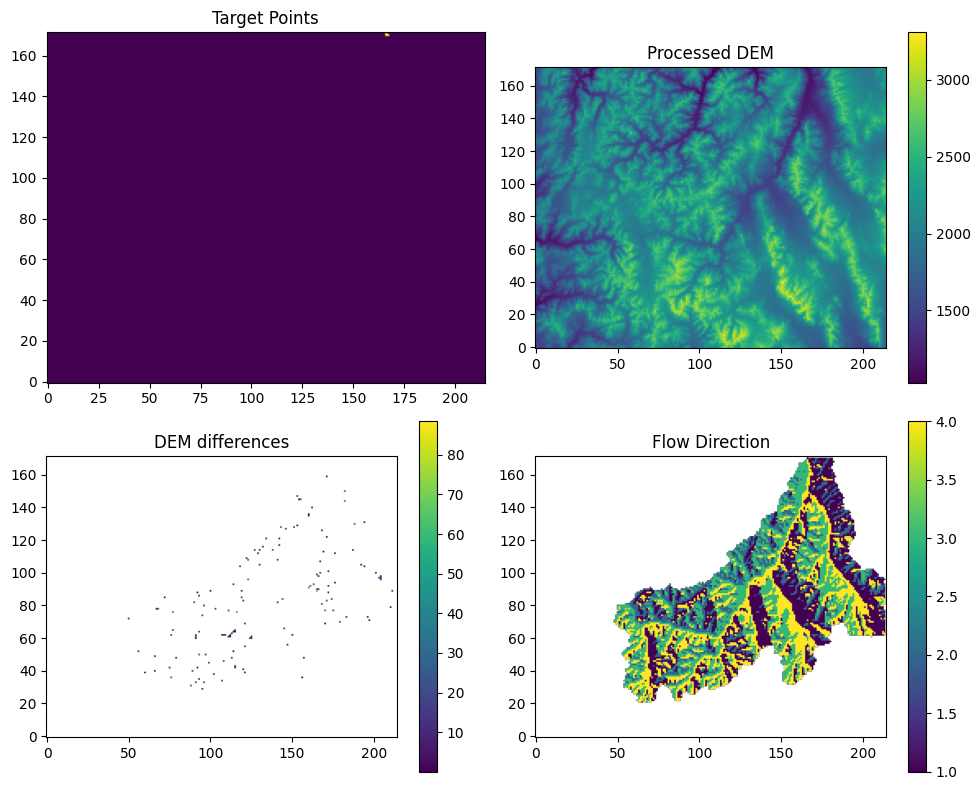

In [75]:
#some calculations for plotting
dem_diff = trav_hs["dem"] - DEM
dem_diff[dem_diff == 0] = np.nan
targets = init["marked"].copy()
targets[targets == 0] = np.nan

#plotting
def _plot_step1(trav_hs, dem_diff, targets):
    """Plot DEM processing results."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes[0, 0].imshow(np.where(np.isnan(targets), 0, 1), cmap='viridis', origin='lower')
    axes[0, 0].set_title("Target Points")
    im1 = axes[0, 1].imshow(trav_hs["dem"], cmap='viridis', origin='lower')
    axes[0, 1].set_title("Processed DEM")
    plt.colorbar(im1, ax=axes[0, 1])
    im2 = axes[1, 0].imshow(dem_diff, cmap='viridis', origin='lower')
    axes[1, 0].set_title("DEM differences")
    plt.colorbar(im2, ax=axes[1, 0])
    im3 = axes[1, 1].imshow(trav_hs["direction"], cmap='viridis', origin='lower')
    axes[1, 1].set_title("Flow Direction")
    plt.colorbar(im3, ax=axes[1, 1])
    plt.tight_layout()
    plt.savefig("workflow_step1.png", dpi=150)
    plt.show()
    plt.close()

_plot_step1(trav_hs, dem_diff, targets)

###  Option 2: If you only want to process your DEM within a pre-defined watershed mask and all border cells of that mask will be used as target exit points
In this case PriorityFlow will define the domain as the area defined by the mask and ensure that  every point in the domain drains to one of the edge points. 

*Note: The mask file should have values of 1 for cells inside the domain and 0 everywhere else.

In [76]:
init = init_queue(DEM, domainmask=watershed_mask)

No init mask provided all border cells will be added to queue
No border provided, setting border using domain mask


In [77]:
#process the DEM
trav_hs = d4_traverse_b(
    DEM.copy(),
    init["queue"].copy(),
    init["marked"].copy(),
    mask=watershed_mask.copy(),
    basins=init["basins"].copy(),
    epsilon=0,
    n_chunk=10,
)

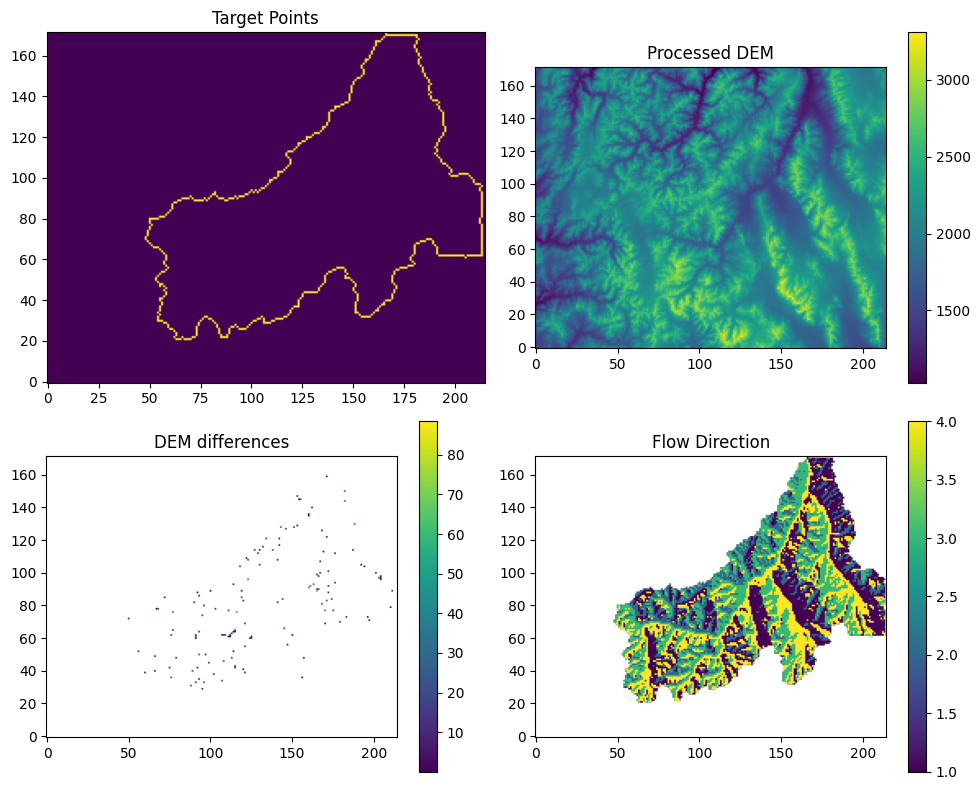

In [78]:
#some calculations for plotting
dem_diff = trav_hs["dem"] - DEM
dem_diff[dem_diff == 0] = np.nan
targets = init["marked"].copy()
targets[targets == 0] = np.nan
#plotting
_plot_step1(trav_hs, dem_diff, targets)

###  Option 3: If you want to have more control over the set of target points used in the processing
Options 1 and 2 both default to using the entire boundary of either the rectangular domain or the watershed mask as the target points for DEM processing. This means that the processing will be counted as complete once every point in the domain has a path to make it to one of the target points. In almost all cases options 1 and 2 will be sufficient. However, you might want more control over the target points in two case:

1. If you have an internally draining basin you might want to specify a point or points on the interior of your domain that count as approved target points. This can be accomplished by providing the InitQueue function with your own border cell file with the border option. 

2. If you are using a watershed boundary and you want to be sure that all of the edges of the domain point in except for your outlet point.  If this is the case you could provide it with a watershed mask as with option 2 but specify only one border point for the InitQueue with the border option. Or you can provide the InitQueue function with a river mask and a watershed mask and it will identify only those points on the watershed mask that touch a boundary of your domain as target outlet points. 

In [79]:
init = init_queue(DEM, domainmask=watershed_mask, initmask=river_mask)

No border provided, setting border using domain mask


In [80]:
#process the DEM
trav_hs = d4_traverse_b(
    DEM.copy(),
    init["queue"].copy(),
    init["marked"].copy(),
    mask=watershed_mask.copy(),
    basins=init["basins"].copy(),
    epsilon=0,
    n_chunk=10,
)

inital queue: 3 Not splitting


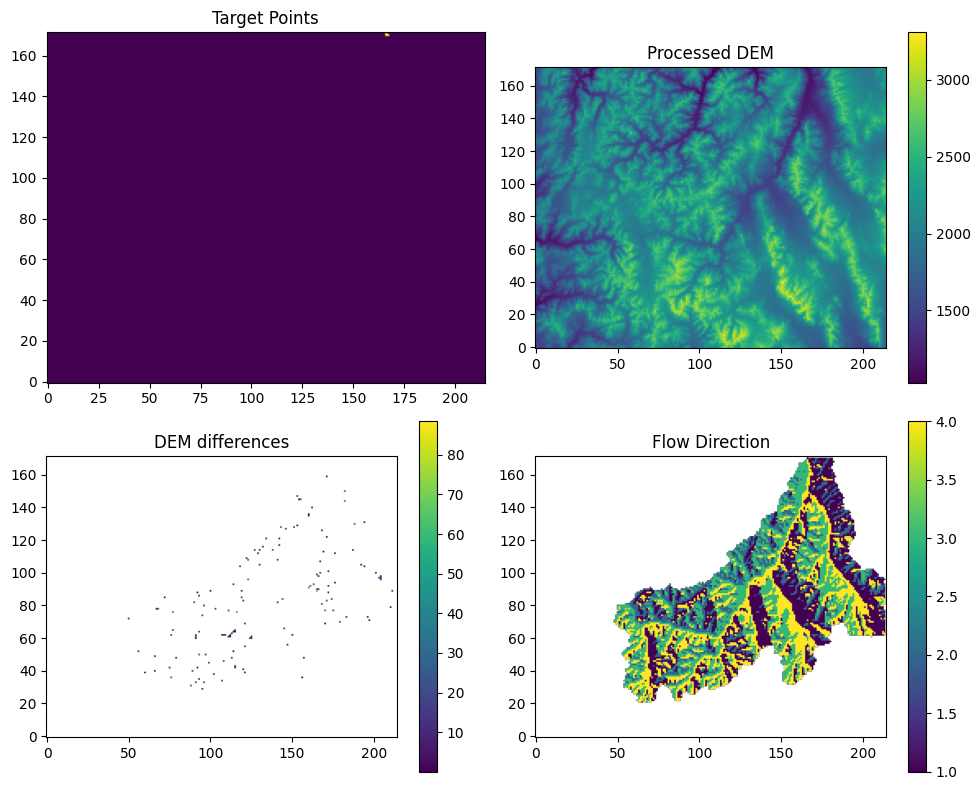

In [81]:
#some calculations for plotting
dem_diff = trav_hs["dem"] - DEM
dem_diff[dem_diff == 0] = np.nan
targets = init["marked"].copy()
targets[targets == 0] = np.nan
#plotting
_plot_step1(trav_hs, dem_diff, targets)

### Option 4: If you want to enforce flow paths along a pre-defined drainage network
In most cases the drainage network results from the standard DEM processing illustrated in the options above will be a good match with expected drainage networks. However, if you have a low resolution DEM or are dealing with a very flat domain the noise in the DEM can result in a drainage network that doesn't match with the know drainage network. In this case you can run a modified workflow where you apply priority flow network processing first along a pre-defined drainage network. Essentially processing just the cells on this drainage network to ensure that they drain out of the domain. Then once this is done do a second pass of processing to ensure that every grid cell not on the pre-defined river network can drain to that network. These steps for this workflow are described in detail in Condon and Maxwell (2019)  and are documented in Downwinding workflows 3 and 4. 

## Step 2: Smoothing along the drainage network
*Step 1* will ensure a drainage network which is fully connected and where all grid cells are guaranteed to drain to one of the target points (usually the edge of the domain). However, there can still be significant noise along the drainage path where jumps in the DEM can impact simulated flow performance. To address this you can do some additional smoothing along the river network. 

### Step 2.1: Calculate drainage areas
Before you can smooth your river network you need to know where it is. To do this you can use the flow direction file created in *Step 1* to calculate the drainage area for every grid cell in the domain.

In [82]:
area = drainage_area(
    trav_hs["direction"],
    mask=watershed_mask,
    printflag=False,
)

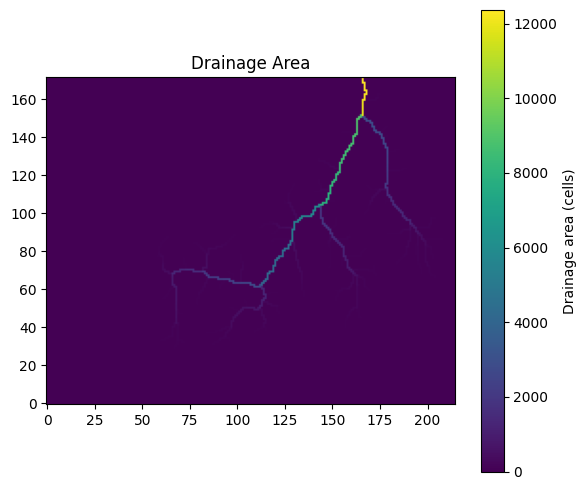

In [83]:
def _plot_drainage_area(area: np.ndarray) -> None:
    """Plot drainage area (like R: image.plot(area, main='drainage Area'))."""
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(area, cmap="viridis", origin='lower')
    ax.set_title("Drainage Area")
    plt.colorbar(im, ax=ax, label="Drainage area (cells)")
    plt.tight_layout()
    plt.savefig("workflow_drainage_area.png", dpi=150)
    plt.show()
    plt.close()

_plot_drainage_area(area)

*Note: In this example I used the watershed mask for the area calculations to be consistent with last DEM processing choices made. However, a mask is not required at this step if you did the DEM processing without applying a mask (i.e. as long as you have flow directions for the whole domain)*

## Step 2.2: Use a drainage area threshold to define a river network
Next you can use the flow direction file and the drainage areas to define a river network given a user specified drainage area threshold to define rivers (i.e. any cell with >=riv_th cells draining to it will count as a river).

In [84]:
# riv_th: cells with >= riv_th cells draining to it count as rivers
subbasin = calc_subbasins(
    trav_hs["direction"],
    area=area,
    mask=watershed_mask,
    riv_th=60,
    merge_th=0,
)

In [85]:
# Calculate stream order (optional)
stream_order = calc_stream_order(
    subbasin["summary"][:, 0],
    subbasin["summary"][:, 5],
    subbasin["segments"].copy(),
)

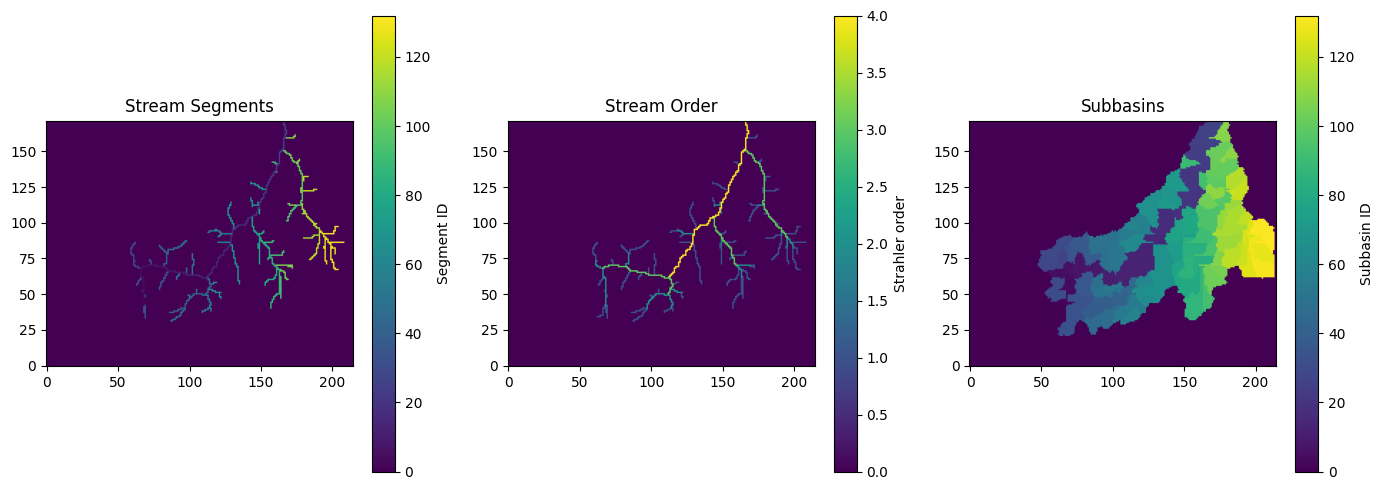

In [87]:
def _plot_stream_network(
    subbasin: dict,
    stream_order: dict,
) -> None:
    """Plot stream segments, stream order, and subbasins (like R par(mfrow=c(1,3)))."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    im0 = axes[0].imshow(subbasin["segments"], cmap="viridis", origin='lower')
    axes[0].set_title("Stream Segments")
    plt.colorbar(im0, ax=axes[0], label="Segment ID")
    im1 = axes[1].imshow(stream_order["order_mask"], cmap="viridis", origin='lower')
    axes[1].set_title("Stream Order")
    plt.colorbar(im1, ax=axes[1], label="Strahler order")
    im2 = axes[2].imshow(subbasin["subbasins"], cmap="viridis", origin='lower')
    axes[2].set_title("Subbasins")
    plt.colorbar(im2, ax=axes[2], label="Subbasin ID")
    plt.tight_layout()
    plt.savefig("workflow_stream_network.png", dpi=150)
    plt.show()
    plt.close()


_plot_stream_network(subbasin, stream_order)

*Note:Try changing the riv_th to change the density of the river network that is created. The merge threshold is used to lump together river segments with drainage areas below this threshold. Use help(CalcSubbasins) to learn more about the options for this function.*

Then, take a look at the resulting river network.

### Step 2.3: Smooth the DEM along river segments
Now you can apply smoothing along your river segments
This function requires:

1. The processed DEM from the PriorityFlow processing in Step 1
2. The flow directions from the PriorityFlow processing in Step 1
3. Information on the starting and ending points of every  river  segment calculated with the subbasin function
4. A map of the river segments from the subbasin function
5. A minimum elevation difference between designated stream cells and non stream cells that are draining to the stream segments (specified here as epsilon). 

This function will calculate the elevation difference from the start to the end of every  segment and apply a constant delta  along the length of the segment to get from the top to the bottom. Then it will traverse back  up the drainage network checking that in the stream adjustment process no stream cells were raised above their surrounding bank cells using the user specified epsilon value to enforce a difference of at least epsilon between bank and stream cells. IF a bank cell needs to be raised to meet the epsilon threshold the algorithm will continue traversing up the hill slope according to the flow direction file raising cells until every neighboring  cell can drain with the required epsilon criteria. 


In [88]:
riv_smooth_result = river_smooth(
    dem=trav_hs["dem"],
    direction=trav_hs["direction"],
    mask=watershed_mask,
    river_summary=subbasin["summary"],
    river_segments=subbasin["segments"],
    bank_epsilon=1,
)

*Note: The mask is optional for this function too. A watershed mask only needs to be provided here if the flow directions were only calculated within the mask in Step 1.*

Now you can do some plotting to see how this smoothing changed the DEM.

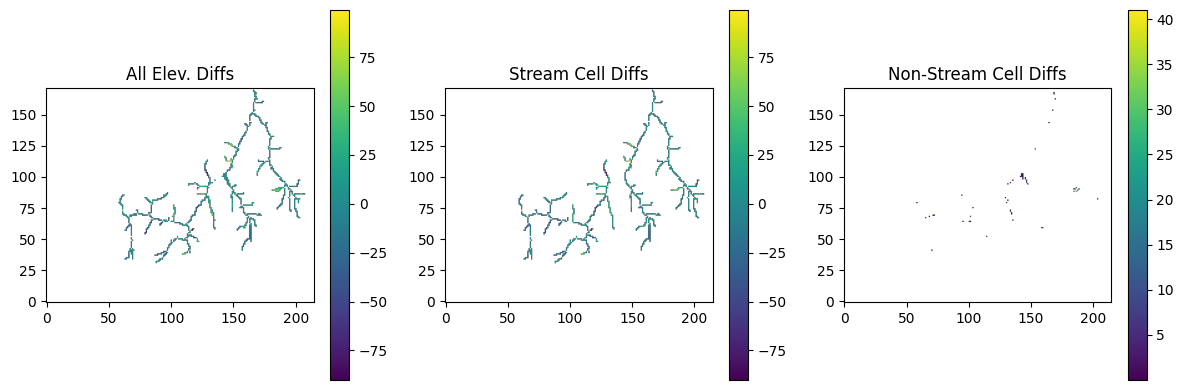

In [90]:
# Plot elevation differences from river smoothing
def _plot_river_smoothing():
    """Plot river smoothing results."""
    dif = riv_smooth_result["dem.adj"] - trav_hs["dem"]
    riv_mask = np.where(subbasin["segments"] > 0, 1, 0)
    hill_mask = 1 - riv_mask
    dif_hill = dif * hill_mask
    dif_riv = dif * riv_mask

    dif_plot = np.where(dif == 0, np.nan, dif)
    dif_riv_plot = np.where(dif_riv == 0, np.nan, dif_riv)
    dif_hill_plot = np.where(dif_hill == 0, np.nan, dif_hill)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    im0 = axes[0].imshow(dif_plot, cmap='viridis', origin='lower')
    axes[0].set_title("All Elev. Diffs")
    plt.colorbar(im0, ax=axes[0])
    im1 = axes[1].imshow(dif_riv_plot, cmap='viridis', origin='lower')
    axes[1].set_title("Stream Cell Diffs")
    plt.colorbar(im1, ax=axes[1])
    if np.any(~np.isnan(dif_hill_plot)):
        im2 = axes[2].imshow(dif_hill_plot, cmap='viridis', origin='lower')
        axes[2].set_title("Non-Stream Cell Diffs")
        plt.colorbar(im2, ax=axes[2])
    plt.tight_layout()
    plt.savefig("workflow_step2_smoothing.png", dpi=150)
    plt.show()
    plt.close()

_plot_river_smoothing()

Also you can use the *path_extract* function to walk downstream from any point in the domain and look at how this processing changed elevations along any flow path. 

For this example I'm using the subbasin['summary'] table to pick one of the stream segment starts as my starting point but you could give the path_extract function any point in the domain as its starting point

In [91]:
segment = 29  # Pick a stream segment (0-indexed, change to see different segment)
start = np.array([[subbasin["summary"][segment, 1], subbasin["summary"][segment, 2]]])

streamline_old = path_extract(
    trav_hs["dem"].copy(),
    trav_hs["direction"].copy(),
    mask=watershed_mask.copy(),
    startpoint=start,
)
streamline_new = path_extract(
    riv_smooth_result["dem.adj"].copy(),
    trav_hs["direction"].copy(),
    mask=watershed_mask.copy(),
    startpoint=start,
)
streamline_riv = path_extract(
    subbasin["segments"].copy(),
    trav_hs["direction"].copy(),
    mask=watershed_mask.copy(),
    startpoint=start,
)

transect_old = streamline_old["data"]
transect_new = streamline_new["data"]
transect_riv = streamline_riv["data"]

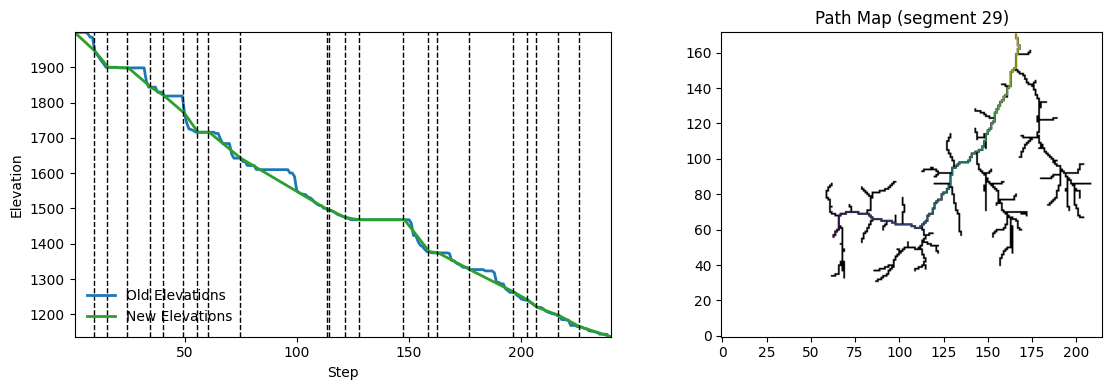

In [93]:
def _plot_path_transect(
    transect_old: np.ndarray,
    transect_new: np.ndarray,
    transect_riv: np.ndarray,
    subbasin: dict,
    streamline_riv: dict,
    segment: int,
) -> None:
    """
    Plot elevation transects and path map along a selected stream segment
    (Python analogue of the R PathExtract plotting block).
    """
    nstep = len(transect_riv)
    x = np.arange(1, nstep + 1)

    # Find breaks between stream segments along the path
    if nstep > 1:
        tr = np.asarray(transect_riv).ravel()
        diff_mask = tr[1:] != tr[:-1]
        slist = np.where(diff_mask)[0] + 1.5  # between steps k and k+1
    else:
        slist = []

    # Elevation limits across old/new transects
    all_vals = np.concatenate(
        [np.asarray(transect_old).ravel(), np.asarray(transect_new).ravel()]
    )
    vmin = np.nanmin(all_vals)
    vmax = np.nanmax(all_vals)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: elevation transects
    ax0 = axes[0]
    ax0.plot(x, transect_old, color="C0", lw=2, label="Old Elevations")
    ax0.plot(x, transect_new, color="C2", lw=2, label="New Elevations")
    ax0.set_xlim(1, max(1, nstep))
    ax0.set_ylim(vmin, vmax)
    for s in slist:
        ax0.axvline(s, color="k", linestyle="--", linewidth=1)
    ax0.set_xlabel("Step")
    ax0.set_ylabel("Elevation")
    ax0.legend(loc="lower left", frameon=False)

    # Right: path map over stream network
    ax1 = axes[1]
    segment_plot = np.where(subbasin["segments"] > 0, 1, 0)
    ax1.imshow(segment_plot, cmap="gray_r", vmin=0, vmax=1)
    ax1.set_title(f"Path Map (segment {segment})")

    path_mask = streamline_riv["path_mask"]
    path_overlay = np.where(path_mask == 0, np.nan, path_mask)
    ax1.imshow(path_overlay, cmap="viridis", alpha=0.8, origin='lower')

    plt.tight_layout()
    plt.savefig("workflow_path_transect.png", dpi=150)
    plt.show()
    plt.close()

_plot_path_transect(transect_old, transect_new, transect_riv, subbasin, streamline_riv, segment)

## Step 3: Calculate the slopes
### 3.1 Calculate the slopes for the entire domain 
Once you have the DEM how you want it you can calculate the slopes for use in ParFlow. Here I am using the *SlopeCalcStan* function which does not do any downwinding and is intended for use with the **OverlandKinematic** or **OverlandDiffusive** boundary conditions in ParFlow. If you are using the **OverlandFlow** boundary condition you should use the *SlopeCalcUP* function documented in the  Downwinding_Workflow_Examples.

The mandatory inputs for this function are:

1. The processed DEM that you would like to calculate the slopes from
2. The flow direction file from *Step 1*
3. The resolution of the DEM: dx, dy (this should be in the same units as your elevations are reported in)

The following optional inputs are also being used here (refer to the help("SlopeCalcStan) for more details):

1. minslope -  This ensures that the magnitude of all slopes is greater than or equal to this value along the flow directions given in the flow direction file
2. maxslope - This sets a global maximum slope magnitude
3. Secondary TH - If this is set to 0 then all slopes not along the primary flow directions (i.e. the x slope for a cell with a primary direction up or down,  or the y slope for a cell with a primary direction to the left or right) will be set to zero. If this is set to the default -1 value no adjustments will be made


In [94]:
slopes_calc = slope_calc_standard(
    dem=riv_smooth_result["dem.adj"].copy(),
    direction=trav_hs["direction"].copy(),
    mask=watershed_mask.copy(),
    minslope=1e-5,
    maxslope=1,
    dx=1000,
    dy=1000,
    secondary_th=-1,
)

## 3.2 Optional
(Adjust the slopes along the river cells). This function allows you to provide an alternate min slope for the primary directions of river cells than was used in the previous step
Also with this function you can remove and seconary slopes (i.e. slopes normal to the primary direciton of flow) that would lead to additional outflow directions in river cells (remove_sec=True)

In [95]:
river_mask_slope = np.where(subbasin["segments"] > 0, 1, 0)
slopes_calc2 = riv_slope(
    direction=trav_hs["direction"].copy(),
    slopex=slopes_calc["slopex"].copy(),
    slopey=slopes_calc["slopey"].copy(),
    minslope=1e-4,
    river_mask=watershed_mask.copy(),
    remove_sec=True,
)

slopex = slopes_calc2["slopex"]
slopey = slopes_calc2["slopey"]

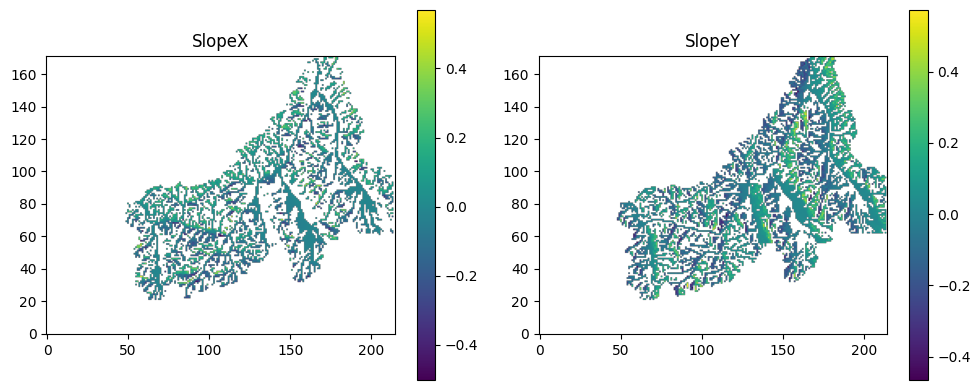

In [97]:
def _plot_slopes(slopex: np.ndarray, slopey: np.ndarray) -> None:
    """
    Plot resulting slopes in x and y directions (R analogue: image.plot of sxplot, syplot).
    """
    sxplot = np.where(slopex == 0, np.nan, slopex)
    syplot = np.where(slopey == 0, np.nan, slopey)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    im0 = axes[0].imshow(sxplot, cmap="viridis", origin='lower')
    axes[0].set_title("SlopeX")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(syplot, cmap="viridis", origin='lower')
    axes[1].set_title("SlopeY")
    plt.colorbar(im1, ax=axes[1])

    plt.tight_layout()
    plt.savefig("workflow_slopes.png", dpi=150)
    plt.show()
    plt.close()


_plot_slopes(slopex, slopey)

## Step 4: Write slope files out in ParFlow pfb format

Any of the matrices calculated here can be written out in any user preferred format. Here I just  provide an example of how to write out the slope files in the standard format needed for ParFlow (PFB). We use the `write_pfb` function from the ParFlow pftools.

In [98]:
write_pfb("slopex.pfb", slopex)
write_pfb("slopey.pfb", slopey)
write_pfb("dem_processed.pfb", riv_smooth_result["dem.adj"])
write_pfb("flow_direction.pfb", trav_hs["direction"])